In [5]:
# from models.preprocessors import BoundingBoxEngineering
from PIL import Image
import pandas as pd
import numpy as np

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from ultralytics import YOLO
from PIL import Image

import pandas as pd
import numpy as np
import torch
import gc
import uuid

class BoundingBoxEngineering(BaseEstimator, TransformerMixin):
    def __init__(self, model = "yolo11n.pt", batch_size = 10, dsample = 128, max_boxes = 10):
        """
        A custom transformer that uses a pre-trained YOLO model to detect pedestrians
        and traffic lights in images, and transforms each image into a list of cropped objects with metadata.
        Args:
            model: The name of the pre-trained YOLO model to use (default: "yolo11n.pt").
            batch_size: The number of images to process in a batch (default: 10).
            dsample: The size to which each cropped object will be resized (default: 128).
            max_boxes: The maximum number of objects to detect and crop from each image (default: 10).
        """
        super().__init__()
        self.model = YOLO(model)
        self.batch_size = batch_size
        self.dsample = (dsample, dsample)
        self.max_boxes = max_boxes

    def fit(self, X, y=None):
        return self

    def fit_transform(self, X, y = None, **fit_params):
        return super().fit_transform(X, y, **fit_params)
    
    def transform(self, X):
        """
        For each image, run the YOLO model to detect pedestrians and traffic 
        lights. For each detected object, crop the image to a square around 
        the bounding box, resize it to 128x128, and concatenate the bounding 
        box coordinates and class label to the pixel values. Return a list 
        of frames, where each frame is a list of cropped objects.

        Args:
            X: A list of file paths to images.
            y: Ignored.

        Returns:
            A list of frames (shape = (n, 10, 128, 128, 8)), where each frame is a 
            list of cropped objects. Each cropped object is a 128x128x8 array, 
            where the first 3 channels are the pixel values, and the last 5 
            channels are the normalized bounding box coordinates and class label.
        """
        shape = (len(X), self.max_boxes, *self.dsample, 8)
        if len(X) > 1000:
            memmap_name = str(uuid.uuid4())
            frames = np.memmap(f'{memmap_name}.dat', dtype='float32', mode='w+', shape=shape)
        else:
            frames = np.zeros(shape, dtype=np.float32)
        
        for i in range(0, len(X), self.batch_size):
            batch_paths = X[i : i + self.batch_size]
            results = self.model(batch_paths, stream=True, verbose=False)
            
            for idx, result in enumerate(results):
                global_id = i + idx
                image = result.orig_img[:, :, ::-1]
                W, H = image.shape[1], image.shape[0]
                frame = np.zeros((self.max_boxes, *self.dsample, 8), dtype=np.float32)
                
                boxes   = result.boxes.xywh.cpu().numpy()
                classes = result.boxes.cls.cpu().numpy()

                order   = np.argsort(boxes[:,2] * boxes[:,3])[::-1]
                boxes   = boxes[order]
                classes = classes[order]

                i = 0
                for box, cls in zip(boxes, classes):
                    if i >= self.max_boxes:
                        break
                    if cls not in [0, 9]:
                        continue
                    x, y, w, h = box
                    
                    cls = (1 if cls == 0 else -1)
                    side = max(w, h) * 1.05

                    x1 = int(max(0, x - side / 2))
                    y1 = int(max(0, y - side / 2))
                    x2 = int(min(W, x + side / 2))
                    y2 = int(min(H, y + side / 2))

                    crop = image[y1:y2, x1:x2]
                    
                    if crop.size == 0:
                        continue
                        
                    crop_resized = np.array(Image.fromarray(crop).resize(self.dsample, Image.LANCZOS)).astype(np.float32) / 255.0
                    meta = np.array([x/W, y/H, w/W, h/H, cls/1], dtype=np.float32)
                    
                    frame[i] = np.concatenate([crop_resized, np.tile(meta, (*self.dsample, 1))], axis=-1)
                    i += 1
                frames[global_id] = frame

            if i % 100 == 0:
                gc.collect()
                torch.cuda.empty_cache()

        return frames

In [ ]:
from sklearn.neighbors import NearestNeighbors
import pandas as pd
import os 

# Read the annotations
path = "C:/Users/rober/OneDrive/Desktop/CS7150/CS7180-Final/data/annotations/bboxes.csv"
annot = pd.read_csv(path,converters={ 'frame': lambda x: f"{int(x):05d}", 'id': str })

# Group metadata into a vector
def metadata(group, limit):
    actual = group[['id', 'content', 'x1', 'y1', 'x2', 'y2', 'occlusion', 'state', 'action', 'gesture', 'cross', 'look']].fillna(0.0).values
    if len(actual) > limit:
        return actual[:limit, :]
    return actual
    # return np.pad(actual, ((0, limit - len(actual)), (0, 0)), mode='constant', constant_values=0)

limit  = 5
frames = annot.groupby(['video', 'frame']).apply(lambda group: metadata(group, limit)).reset_index()

# bb = BoundingBoxEngineering(dsample = 128, max_boxes = limit)
folder = "C:/Users/rober/OneDrive/Desktop/CS7150/CS7180-Final/data/images/set01"
for video, frame, meta in frames.loc[(frames.video == 'video_0003')&(frames.frame == '09850'), :].values:
    orig = Image.open(f"{folder}/{video}/{frame}.png")
    W, H = orig.size
    mask = np.zeros((H, W, 3), dtype=np.uint8) 
    for id, content, x1, y1, x2, y2, occlusion, state, action, gesture, cross, look in meta:
        img = np.array(orig)
        x, y = (x2 + x1) / 2, (y2 + y1) / 2
        w, h = (x2 - x1), (y2 - y1)
        side = max(w, h) * 1.2
        
        x1 = int(max(0, x - side / 2))
        y1 = int(max(0, y - side / 2))
        x2 = int(min(W, x + side / 2))
        y2 = int(min(H, y + side / 2))
        
        mask[int(y1):int(y2), int(x1):int(x2)] = 1
        img[mask==0] = 0
        mask *= 0

        masked = Image.fromarray(img)
    break



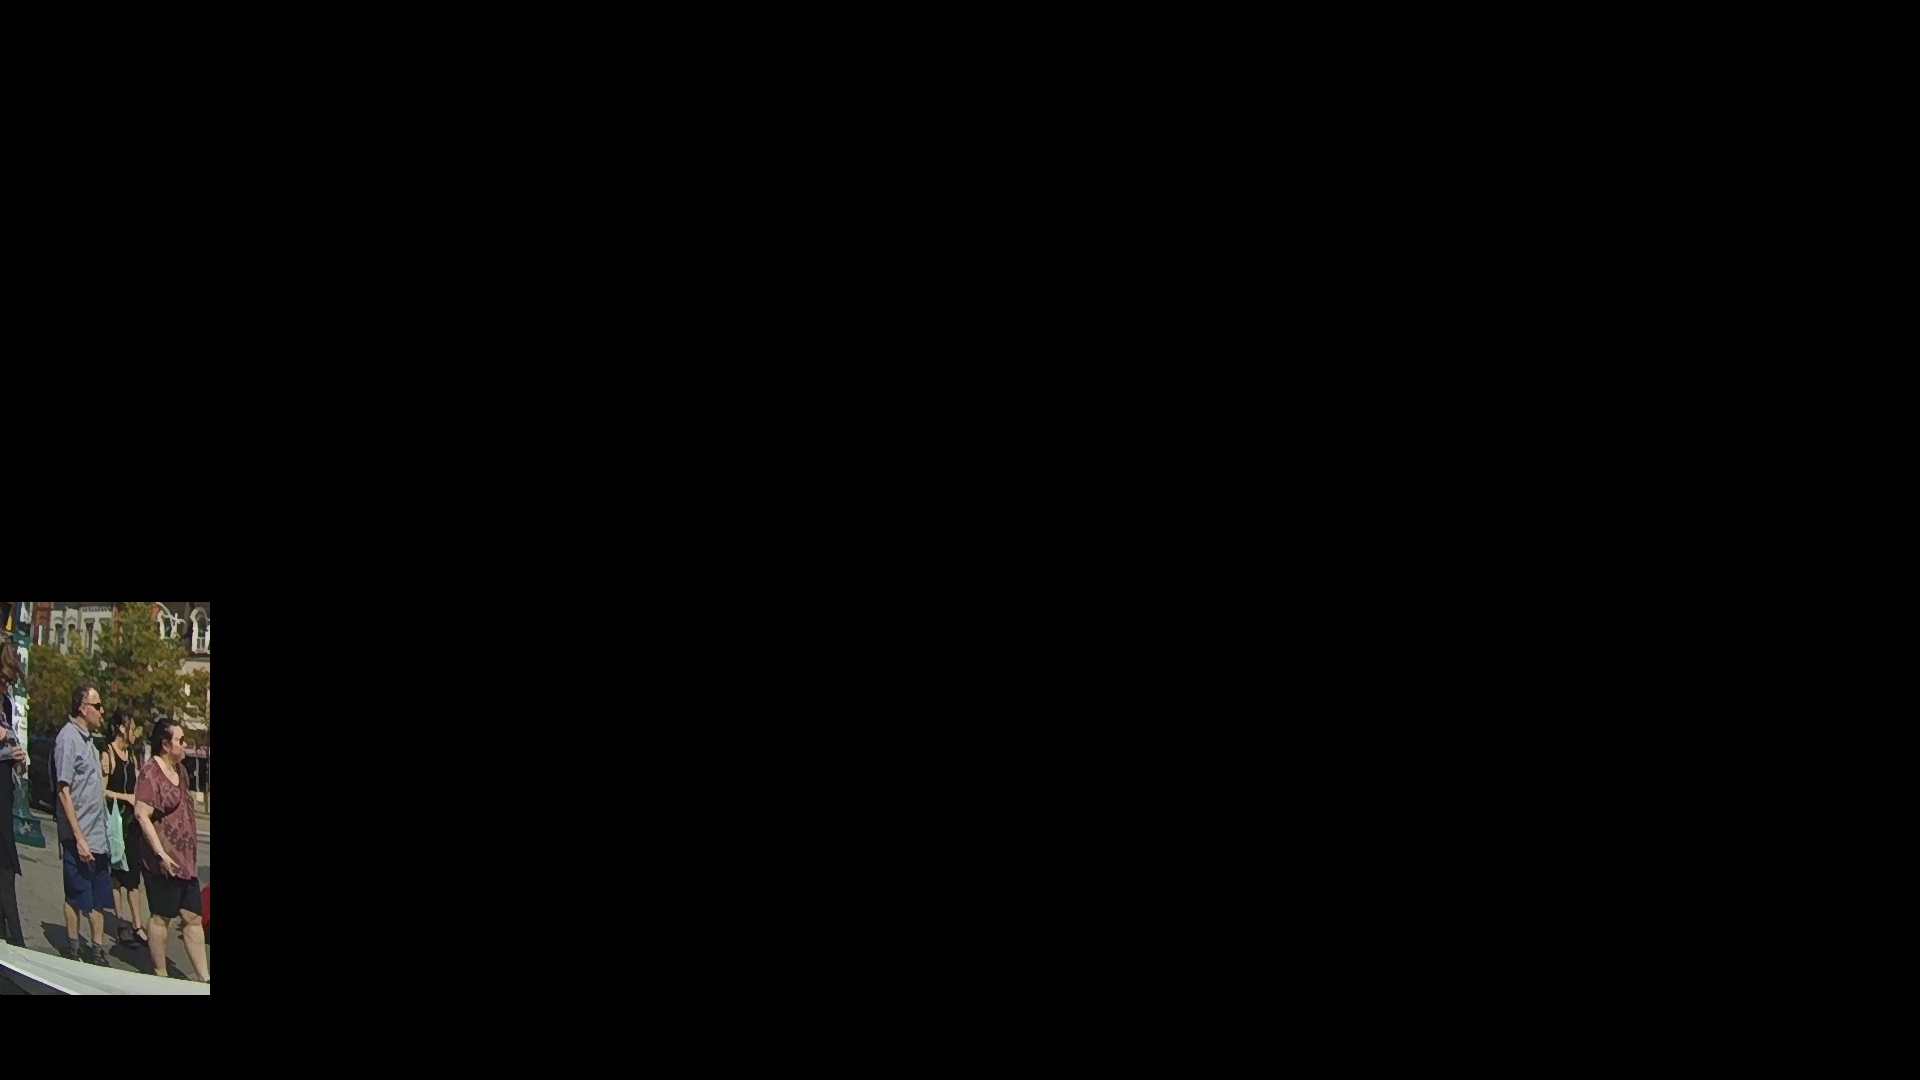

In [112]:
masked

In [73]:
Image.fromarray(mask).show()

In [48]:
boxes.shape#[:,:,0,0,3:]

(1, 5, 128, 128, 8)

In [60]:
knn = NearestNeighbors(n_neighbors=1).fit(meta[:, :2])
knn.kneighbors(boxes[0,:,0,0,3:5], return_distance=False)

array([[0],
       [1],
       [0],
       [0],
       [4]])

In [57]:
meta[:,:2]

array([[    0.44562,     0.63269],
       [    0.34319,     0.65612],
       [    0.48073,     0.75946],
       [    0.48102,     0.76077],
       [          0,           0]])

In [55]:
boxes[:, :, 0, 0, 3:5]

array([[[    0.72609,     0.55797],
        [   0.018441,     0.47656],
        [    0.72813,     0.55915],
        [    0.44554,     0.63089],
        [          0,           0]]], dtype=float32)

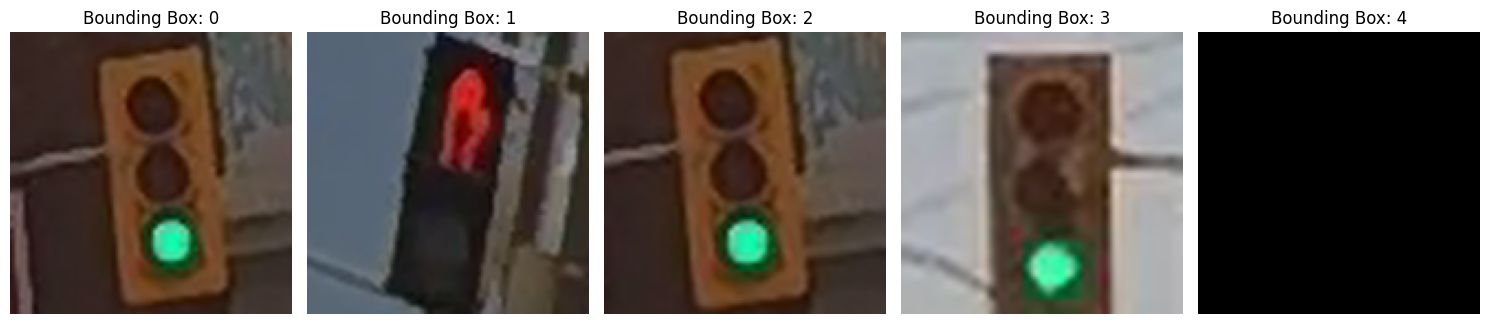

In [40]:
from PIL import Image
import matplotlib.pyplot as plt

boxes = 5
bb = BoundingBoxEngineering(
    dsample=128,
    max_boxes=boxes
)
results = bb.transform([file])

fig, axes = plt.subplots(1, boxes, figsize=(15, 5))

# 3. Loop through the paths and axes to plot
for i in range(boxes):
    img = (results[0,i,:,:,:3] * 255).astype(np.uint8)
    axes[i].imshow(img)
    axes[i].axis('off')  # Hide ticks and labels
    axes[i].set_title(f"Bounding Box: {i}") # Optional: set title to filename

plt.tight_layout()
plt.show()

In [ ]:
import os
import numpy as np

path = "C:/Users/rober/OneDrive/Desktop/CS7150/CS7180-Final/data/annotations/bboxes.csv"
annot = pd.read_csv(path,converters={ 'frame': lambda x: f"{int(x):05d}", 'id': str })

folder_path = r"C:/Users/rober/OneDrive/Desktop/CS7150/CS7180-Final/data/images/cropped"
imgs = [f"{folder_path}/{f}" for f in os.listdir(folder_path)]

bb = BoundingBoxEngineering(batch_size=10, max_boxes=1)
results = bb.transform(imgs)

files = pd.DataFrame([file.split('/')[-1].split('.')[0].split('-') for file in imgs], columns=['video', 'frame', 'content', 'id'])
files = files.merge(annot, on=['video', 'frame', 'content', 'id'], how='left').fillna(0)

labels = files[['occlusion','state','action','gesture','cross','look']].values.astype(np.float32)
labels_broadcasted = np.broadcast_to(labels[:, np.newaxis, np.newaxis, np.newaxis, :], (68700, 1, 128, 128, 6))

# data = np.concatenate([results, labels_broadcasted], axis=-1)
np.save('C:/Users/rober/OneDrive/Desktop/CS7150/CS7180-Final/data/annotations/vectorized-frames.npy', results)

In [ ]:
path = '.../vectorized-video-frames-labelled.bin'
results = np.memmap(path, dtype='float32', mode='r', shape=(68700, 1, 128, 128, 14))

In [49]:
import numpy as np

# 1. Define final shape and path
final_shape = (68700, 1, 128, 128, 14)
file_path = 'C:/Users/rober/OneDrive/Desktop/CS7150/CS7180-Final/data/annotations/vectorized-frame-2.bin'

# 2. Create the file on disk (w+ means write/create)
# This will take up 58.7 GiB of disk space immediately
data_mmap = np.memmap(file_path, dtype='float32', mode='w+', shape=final_shape)

# 3. Insert 'results' into the first 8 channels
data_mmap[..., :8] = results
data_mmap.flush()  # Forces write to disk

# 4. Insert labels into the last 6 channels
# We do this in one step because labels_broadcasted already exists in your RAM
data_mmap[..., 8:] = labels_broadcasted
data_mmap.flush()

print(f"Success! Data saved to {file_path}")

Success! Data saved to C:/Users/rober/OneDrive/Desktop/CS7150/CS7180-Final/data/annotations/vectorized-frame-2.bin


In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_array, check_is_fitted
from typing import List, Tuple
from tqdm import tqdm

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

class ConvolutionalNeuralNetwork(nn.Module, BaseEstimator, TransformerMixin):
    def __init__(
            self,
            epoch: int = 10,
            learning_rate: float = 0.1,
            layers: List[torch.nn.Module] = [],
            criterion: str = 'CrossEntropyLoss',
            optimizer: str = 'Adam',
            batch_size: int = 100,
            minimum_change: float = 0.0,
            seed: int = 0
        ):
        super(ConvolutionalNeuralNetwork, self).__init__()

        if layers is None:
            raise ValueError("Need layers bro!")

        self.losses: List[float] = []
        self.epoch: int = epoch
        self.learning_rate: float = learning_rate
        self.layers: List[torch.nn.Module] = nn.Sequential(*layers)
        self.criterion: str = criterion
        self.optimizer: str = optimizer
        self.batch_size: int = batch_size
        self.minimum_change: float = minimum_change
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.to(self.device)
        self.seed: int = seed
        torch.manual_seed(self.seed)

    def forward(self, X: np.ndarray) -> np.ndarray:
        return self.layers(X)

    def transform(self, X: np.ndarray) -> np.ndarray:
        """
        Extracts deep features from the image channels (0-2) and 
        concatenates them with the metadata (3-7).
        """
        # 1. Separate Images and Metadata
        # Images: (N, 224, 224, 0:3) | Metadata: (N, 224, 224, 3:8)
        images = torch.tensor(X[:, :, :, :3], dtype=torch.float32).permute(0, 3, 1, 2).to(self.device)
        
        # Extract metadata from the first pixel of each crop (since it's tiled)
        metadata = X[:, 0, 0, 3:] 

        self.eval()
        with torch.no_grad():
            # 2. Pass through the CNN layers
            features = self.forward(images)
            
            # 3. Flatten the spatial dimensions if the CNN output is still 4D
            # (Batch, Channels, 1, 1) -> (Batch, Channels)
            flat_features = torch.flatten(features, start_dim=1).cpu().numpy()

        # 4. Concatenate Smart Features with Raw Metadata
        return np.concatenate([flat_features, metadata], axis=1)

    def fit_transform(self, X: np.ndarray, y: np.array = None) -> np.ndarray:
        self.fit(X, y)
        return self.transform(X)

    def fit(self, X: np.ndarray, y: np.array) -> np.ndarray:
        y = torch.tensor(y, dtype=torch.long).to(self.device)
        X = torch.tensor(X[:, :, :, :3], dtype=torch.float32).permute(0, 3, 1, 2).to(self.device)

        criterion = getattr(torch.nn, self.criterion)()
        optimizer = getattr(torch.optim, self.optimizer)(self.parameters(), lr=self.learning_rate, weight_decay=0.001)

        dataset = torch.utils.data.TensorDataset(X, y)
        dataloader = torch.utils.data.DataLoader(dataset, batch_size=self.batch_size, shuffle=True)

        for _ in tqdm(range(self.epoch)):
            loss: float = 0.0
            for X_batch, y_batch in dataloader:
                # Forward pass
                y_batch_pred = self.forward(X_batch)
                batch_loss = criterion(y_batch_pred, y_batch)
                loss += batch_loss.item()

                # Backward and optimize
                optimizer.zero_grad()
                batch_loss.backward()
                optimizer.step()
            self.losses.append(loss / len(dataloader))
            if len(self.losses) > 1 and abs(self.losses[-2] - self.losses[-1]) <= self.minimum_change:
                break

        print("Loss: {}".format(self.losses[-1]))
        return self